# Latent space

***Info***: The process of choosing latent dimension took 6 hours for each omics data type.



In [ ]:
# Define the custom Autoencoder
class Autoencoder(Model):
    def __init__(self, input_dim, latent_dim, activation):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.activation = activation

        # Encoder
        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(input_dim,)),
            layers.Dense(128, activation=self.activation),
            layers.Dense(64, activation=self.activation),
            layers.Dense(latent_dim, activation=self.activation)
        ])

        # Decoder
        self.decoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(64, activation=self.activation),
            layers.Dense(128, activation=self.activation),
            layers.Dense(input_dim, activation='sigmoid')  # Output fixed to sigmoid
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

# Define loss function
def compute_ae_loss(x, reconstructed):
    return tf.keras.losses.MeanSquaredError()(x, reconstructed)

# Define training procedure
def train_autoencoder(model, X, epochs=100, lr=1e-3):
    """
    Trains the Keras Autoencoder model using TensorFlow.
    """
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    criterion = tf.keras.losses.MeanSquaredError()  # Keras loss function
    X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)  # Convert to Tensor

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            recon = model(X_tensor)  # Keras model call
            loss = criterion(X_tensor, recon)  # Calculate loss
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        if (epoch + 1) % 10 == 0:  # Print loss every 10 epochs
            print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.numpy():.4f}")

    return model

In [ ]:
def get_graph_metrics(adj_matrix):
    # Binarize
    binary = (np.abs(adj_matrix) > 1e-3).astype(int)
    G = nx.from_numpy_array(binary, create_using=nx.DiGraph)

    # Sparsity
    sparsity = 1.0 - (binary.sum() / binary.size)

    # DAG-ness: number of cycles (0 = perfect DAG)
    try:
        cycles = nx.find_cycle(G, orientation="original")
        dagness = len(cycles)
    except:
        dagness = 0

    return sparsity, dagness

In [ ]:
def graph_jaccard(A1, A2):
    A1_bin = (np.abs(A1) > 1e-3).astype(int)
    A2_bin = (np.abs(A2) > 1e-3).astype(int)
    intersection = np.logical_and(A1_bin, A2_bin).sum()
    union = np.logical_or(A1_bin, A2_bin).sum()
    return intersection / (union + 1e-6)

def bootstrap_stability(latent, n_boot=10, frac=0.8):
    jaccards = []
    n = latent.shape[0]
    for _ in range(n_boot):
        idx1 = np.random.choice(n, int(frac * n), replace=True)
        idx2 = np.random.choice(n, int(frac * n), replace=True)
        A1 = DirectLiNGAM().fit(latent[idx1]).adjacency_matrix_
        A2 = DirectLiNGAM().fit(latent[idx2]).adjacency_matrix_
        jaccards.append(graph_jaccard(A1, A2))
    return np.mean(jaccards)

In [ ]:
bottlenecks = [50, 100, 150]
results = []

X = norm_df.values.astype(np.float32)
for b in bottlenecks:
    print(f"Testing bottleneck size: {b}")
    model = Autoencoder(input_dim=X.shape[1], latent_dim=b, activation='relu')
    model = train_autoencoder(model, X)  # Using TensorFlow train_autoencoder

    # Get latent space representation using TensorFlow
    Z = model.encoder.predict(X)


    # DirectLiNGAM
    dag = DirectLiNGAM().fit(Z)
    A = dag.adjacency_matrix_

    # Metrics
    sparsity, dagness = get_graph_metrics(A)
    stability = bootstrap_stability(Z)

    results.append({
        "bottleneck": b,
        "sparsity": sparsity,
        "dagness": dagness,
        "stability": stability
    })

Testing bottleneck size: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 0.6015
Epoch [20/100], Loss: 0.5677
Epoch [30/100], Loss: 0.5486
Epoch [40/100], Loss: 0.5348
Epoch [50/100], Loss: 0.5215
Epoch [60/100], Loss: 0.5082
Epoch [70/100], Loss: 0.4982
Epoch [80/100], Loss: 0.4893
Epoch [90/100], Loss: 0.4804
Epoch [100/100], Loss: 0.4718
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 100
Epoch [10/100], Loss: 0.6036
Epoch [20/100], Loss: 0.5879
Epoch [30/100], Loss: 0.5645
Epoch [40/100], Loss: 0.5487
Epoch [50/100], Loss: 0.5332
Epoch [60/100], Loss: 0.5174
Epoch [70/100], Loss: 0.5049
Epoch [80/100], Loss: 0.4947
Epoch [90/100], Loss: 0.4855
Epoch [100/100], Loss: 0.4762
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 0.6036
Epoch [20/100], Loss: 0.6000
Epoch [30/100], Loss: 0.5764
Epoch [40/100], Loss: 0.5637
Epoch [50/100], Loss: 0.5486
Epoch [60/100], Loss: 0.5324
Epoch [70/100], Loss: 0.5185
Epoch [80/100], Loss: 0.5055
Epoch [90/100], Loss: 0.4938
Epoch [100/100], Loss: 0.4813
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

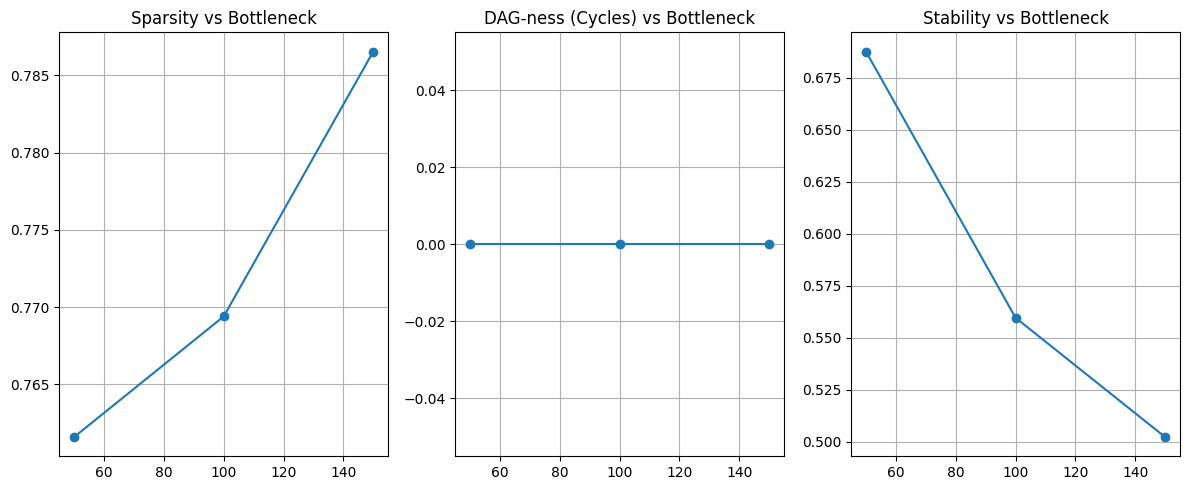

In [ ]:
df = pd.DataFrame(results)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(df["bottleneck"], df["sparsity"], marker='o')
plt.title("Sparsity vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(df["bottleneck"], df["dagness"], marker='o')
plt.title("DAG-ness (Cycles) vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(df["bottleneck"], df["stability"], marker='o')
plt.title("Stability vs Bottleneck")
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
bottlenecks = [50, 100, 150]
results1 = []

X1 = norm_df1.values.astype(np.float32)
for b in bottlenecks:
    print(f"Testing bottleneck size: {b}")
    model = Autoencoder(input_dim=X1.shape[1], latent_dim=b, activation='relu')
    model = train_autoencoder(model, X1)  # Using TensorFlow train_autoencoder

    # Get latent space representation using TensorFlow
    Z1 = model.encoder.predict(X1)


    # DirectLiNGAM
    dag1 = DirectLiNGAM().fit(Z1)
    A1 = dag1.adjacency_matrix_

    # Metrics
    sparsity, dagness = get_graph_metrics(A1)
    stability = bootstrap_stability(Z1)

    results1.append({
        "bottleneck": b,
        "sparsity": sparsity,
        "dagness": dagness,
        "stability": stability
    })

Testing bottleneck size: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 0.0207
Epoch [20/100], Loss: 0.0150
Epoch [30/100], Loss: 0.0139
Epoch [40/100], Loss: 0.0135
Epoch [50/100], Loss: 0.0134
Epoch [60/100], Loss: 0.0133
Epoch [70/100], Loss: 0.0132
Epoch [80/100], Loss: 0.0132
Epoch [90/100], Loss: 0.0130
Epoch [100/100], Loss: 0.0123
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 100
Epoch [10/100], Loss: 0.0211
Epoch [20/100], Loss: 0.0149
Epoch [30/100], Loss: 0.0139
Epoch [40/100], Loss: 0.0135
Epoch [50/100], Loss: 0.0134
Epoch [60/100], Loss: 0.0133
Epoch [70/100], Loss: 0.0132
Epoch [80/100], Loss: 0.0130
Epoch [90/100], Loss: 0.0124
Epoch [100/100], Loss: 0.0108
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 150
Epoch [10/100], Loss: 0.0238
Epoch [20/100], Loss: 0.0149
Epoch [30/100], Loss: 0.0140
Epoch [40/100], Loss: 0.0136
Epoch [50/100], Loss: 0.0135
Epoch [60/100], Loss: 0.0133
Epoch [70/100], Loss: 0.0133
Epoch [80/100], Loss: 0.0132
Epoch [90/100], Loss: 0.0132
Epoch [100/100], Loss: 0.0129
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_vari

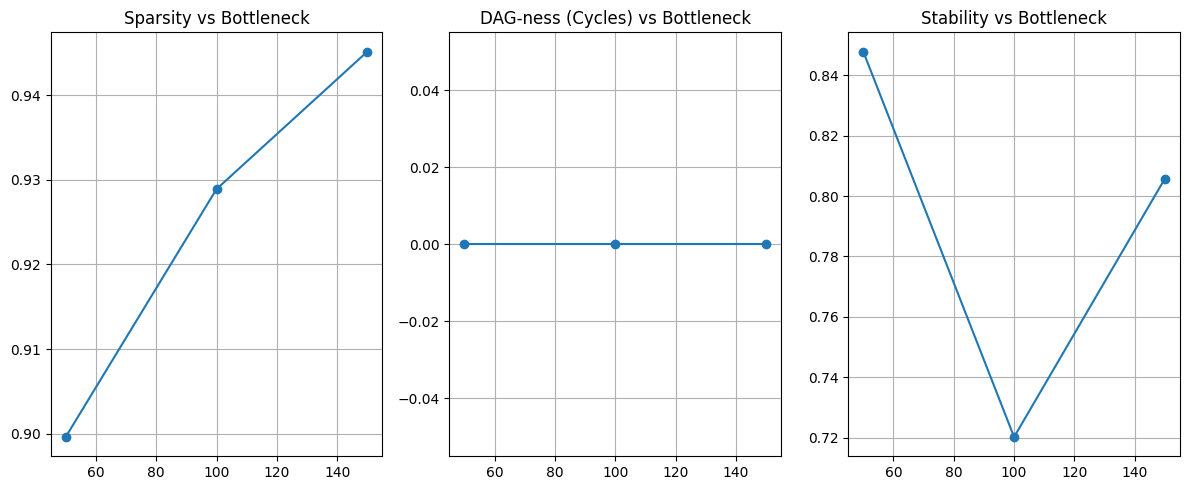

In [ ]:
df = pd.DataFrame(results1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(df["bottleneck"], df["sparsity"], marker='o')
plt.title("Sparsity vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(df["bottleneck"], df["dagness"], marker='o')
plt.title("DAG-ness (Cycles) vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(df["bottleneck"], df["stability"], marker='o')
plt.title("Stability vs Bottleneck")
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
bottlenecks = [50, 100,150]
results2 = []

X2 = norm_df2.values.astype(np.float32)
for b in bottlenecks:
    print(f"Testing bottleneck size: {b}")
    model = Autoencoder(input_dim=X2.shape[1], latent_dim=b, activation='relu')
    model = train_autoencoder(model, X2)  # Using TensorFlow train_autoencoder

    # Get latent space representation using TensorFlow
    Z2 = model.encoder.predict(X2)


    # DirectLiNGAM
    dag2 = DirectLiNGAM().fit(Z2)
    A2 = dag2.adjacency_matrix_

    # Metrics
    sparsity, dagness = get_graph_metrics(A2)
    stability = bootstrap_stability(Z2)

    results2.append({
        "bottleneck": b,
        "sparsity": sparsity,
        "dagness": dagness,
        "stability": stability
    })

Testing bottleneck size: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 1.1297
Epoch [20/100], Loss: 0.9697
Epoch [30/100], Loss: 0.9329
Epoch [40/100], Loss: 0.8893
Epoch [50/100], Loss: 0.8470
Epoch [60/100], Loss: 0.8113
Epoch [70/100], Loss: 0.7889
Epoch [80/100], Loss: 0.7727
Epoch [90/100], Loss: 0.7584
Epoch [100/100], Loss: 0.7473
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: Runtime

Testing bottleneck size: 100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 1.1224
Epoch [20/100], Loss: 0.9607
Epoch [30/100], Loss: 0.9276
Epoch [40/100], Loss: 0.8944
Epoch [50/100], Loss: 0.8617
Epoch [60/100], Loss: 0.8299
Epoch [70/100], Loss: 0.8061
Epoch [80/100], Loss: 0.7888
Epoch [90/100], Loss: 0.7753
Epoch [100/100], Loss: 0.7629
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 150
Epoch [10/100], Loss: 1.0982
Epoch [20/100], Loss: 0.9606
Epoch [30/100], Loss: 0.9189
Epoch [40/100], Loss: 0.8784
Epoch [50/100], Loss: 0.8437
Epoch [60/100], Loss: 0.8151
Epoch [70/100], Loss: 0.7945
Epoch [80/100], Loss: 0.7775
Epoch [90/100], Loss: 0.7641
Epoch [100/100], Loss: 0.7523
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

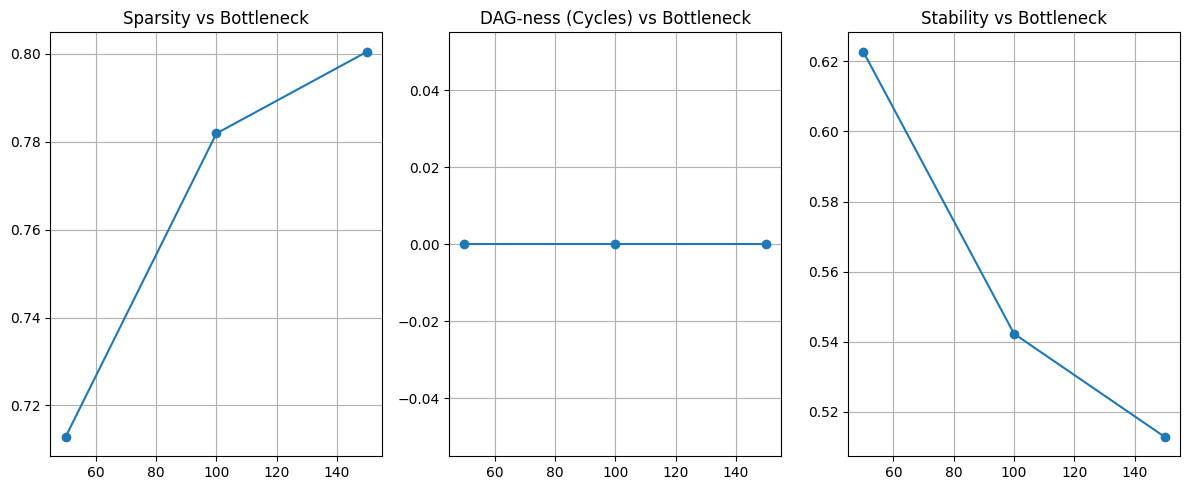

In [ ]:
df = pd.DataFrame(results2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(df["bottleneck"], df["sparsity"], marker='o')
plt.title("Sparsity vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(df["bottleneck"], df["dagness"], marker='o')
plt.title("DAG-ness (Cycles) vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(df["bottleneck"], df["stability"], marker='o')
plt.title("Stability vs Bottleneck")
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
bottlenecks = [50, 100,150]
results3 = []

X3 = norm_df3.values.astype(np.float32)
for b in bottlenecks:
    print(f"Testing bottleneck size: {b}")
    model = Autoencoder(input_dim=X3.shape[1], latent_dim=b, activation='relu')
    model = train_autoencoder(model, X3)  # Using TensorFlow train_autoencoder

    # Get latent space representation using TensorFlow
    Z3 = model.encoder.predict(X3)


    # DirectLiNGAM
    dag3 = DirectLiNGAM().fit(Z3)
    A3 = dag3.adjacency_matrix_

    # Metrics
    sparsity, dagness = get_graph_metrics(A3)
    stability = bootstrap_stability(Z3)

    results3.append({
        "bottleneck": b,
        "sparsity": sparsity,
        "dagness": dagness,
        "stability": stability
    })

Testing bottleneck size: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 0.1274
Epoch [20/100], Loss: 0.1251
Epoch [30/100], Loss: 0.1251
Epoch [40/100], Loss: 0.1251
Epoch [50/100], Loss: 0.1251
Epoch [60/100], Loss: 0.1251
Epoch [70/100], Loss: 0.1251
Epoch [80/100], Loss: 0.1251
Epoch [90/100], Loss: 0.1251
Epoch [100/100], Loss: 0.1251
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch [10/100], Loss: 0.1261
Epoch [20/100], Loss: 0.1251
Epoch [30/100], Loss: 0.1251
Epoch [40/100], Loss: 0.1251
Epoch [50/100], Loss: 0.1251
Epoch [60/100], Loss: 0.1251
Epoch [70/100], Loss: 0.1251
Epoch [80/100], Loss: 0.1251
Epoch [90/100], Loss: 0.1251
Epoch [100/100], Loss: 0.1251
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

Testing bottleneck size: 150
Epoch [10/100], Loss: 0.1256
Epoch [20/100], Loss: 0.1251
Epoch [30/100], Loss: 0.1251
Epoch [40/100], Loss: 0.1251
Epoch [50/100], Loss: 0.1251
Epoch [60/100], Loss: 0.1251
Epoch [70/100], Loss: 0.1251
Epoch [80/100], Loss: 0.1251
Epoch [90/100], Loss: 0.1251
Epoch [100/100], Loss: 0.1251
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:223: RuntimeWarning: invalid value encountered in divide
  xi_std = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:224: RuntimeWarning: invalid value encountered in divide
  xj_std = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])
/usr/local/lib/python3.12/dist-packages/lingam/direct_lingam.py:151: RuntimeWarning: invalid value encountered in scalar divide
  return xi - (np.cov(xi, xj, bias=True)[0, 1] / np.var(xj)) * xj
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2301: RuntimeWarning: divide by zero encountered in log
  n_samples * np.log(2 * np.pi * self.noise_variance_)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:2302: RuntimeWarning: invalid value encountered in divide
  + residuals_sum_squares / self.noise_variance_
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py

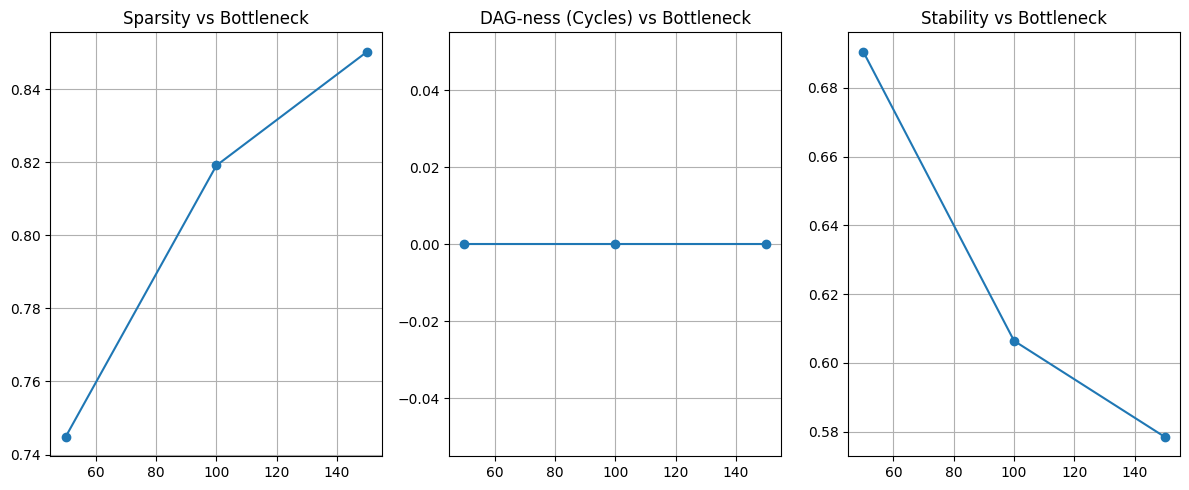

In [ ]:
df = pd.DataFrame(results3)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(df["bottleneck"], df["sparsity"], marker='o')
plt.title("Sparsity vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(df["bottleneck"], df["dagness"], marker='o')
plt.title("DAG-ness (Cycles) vs Bottleneck")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(df["bottleneck"], df["stability"], marker='o')
plt.title("Stability vs Bottleneck")
plt.grid()

plt.tight_layout()
plt.show()